# Tarea 3: Habilidades socioemocionales, entorno familiar y empleo materno
### Pablo Ignacio Cortés Vielma
### 2021458476
### Ingeniería civil industrial



Se analiza la base de datos "junaeb2n.csv", que contiene mediciones de habilidades socioemocionales, variables del entorno familiar y un indicador de empleo materno para estudiantes evaluados por la JUNAEB. El flujo metodológico recorre la limpieza y exploración de los datos, la reducción de dimensionalidad mediante Análisis Factorial Exploratorio (EFA) y Confirmatorio (CFA), la clasificación supervisada del empleo materno (Random Forest, XGBoost, SVM y Stacking), el clustering no supervisado del estado nutricional y, finalmente, un modelo de Procesamiento de Lenguaje Natural (NLP) sobre las narrativas generadas.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn

# --- Análisis factorial (EFA / CFA) ---
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

# --- Machine Learning supervisado ---
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score,
                                     StratifiedKFold, RepeatedStratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# --- Clustering ---
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)

# --- NLP ---
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
for _pkg in ['punkt', 'punkt_tab', 'stopwords']:
    nltk.download(_pkg, quiet=True)

# Configuración visual y reproducibilidad
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.options.display.float_format = '{:.3f}'.format
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Pregunta 1: Carga, exploración y limpieza de datos

Cargamos la base de datos "junaeb2n.csv" e identificamos los tipos de datos, analizamos la presencia de valores faltantes, evaluamos las distribuciones y outliers de las variables clave

In [2]:
# Carga de la base de datos (data original del repositorio)
df = pd.read_csv('../../data/junaeb2n.csv')

print("Dimensiones de la base de datos:", df.shape)
df.info()

Dimensiones de la base de datos: (41854, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non

### Identificación de los tipos de datos

| Tipo | Variables | Naturaleza |
|------|-----------|------------|
| Continuas | "imce" (IMC estandarizado, puntaje z), "edad" (meses), "educm", "educp" (años de escolaridad) | Numéricas de razón/intervalo |
| Ordinales | "sk1"-"sk13" (escala Likert 1-5), "act_fisica" (1-5) | Orden con distancia no necesariamente uniforme |
| Nominales / binarias | "sexo" (1=mujer), "area" (1=urbana), "vive_padre", "vive_madre" | Categóricas |
| Objetivo | "madre_work" (-1=labor doméstica, 0=desempleada, 1=empleada) | Categórica nominal |
| Texto | "narrative" | Texto generado a partir de "sk1"-"sk13" |

In [3]:
# Estadísticas descriptivas de las variables continuas
sks = [f'sk{i}' for i in range(1, 14)]
continuas = ['imce', 'edad', 'educm', 'educp']
print("Estadísticas descriptivas de variables continuas")
display(df[continuas].describe().T)

print("\nRango de los ítems socioemocionales sk1-sk13 (escala Likert 1-5)")
display(df[sks].describe().T[['min', 'max', 'mean', 'std']])

Estadísticas descriptivas de variables continuas


,count,mean,std,min,25%,50%,75%,max
imce,41854.000,1.014,1.380,-5.020,0.100,0.970,1.930,5.040
edad,41854.000,83.066,3.987,62.000,81.000,82.000,84.000,107.000
educm,41303.000,12.975,3.374,0.000,11.000,13.000,15.000,22.000
educp,41854.000,12.897,3.462,0.000,11.000,13.000,14.000,22.000



Rango de los ítems socioemocionales sk1-sk13 (escala Likert 1-5)


,min,max,mean,std
sk1,1.000,5.000,1.118,0.401
sk2,1.000,5.000,1.397,0.662
sk3,1.000,5.000,1.270,0.594
sk4,1.000,5.000,1.263,0.589
sk5,1.000,5.000,1.276,0.575
sk6,1.000,5.000,1.497,0.747
sk7,1.000,5.000,2.257,1.225
sk8,1.000,5.000,1.565,0.846
sk9,1.000,5.000,1.347,0.682
sk10,1.000,5.000,1.887,0.959


### Exploración visual de los datos faltantes

Valores faltantes por variable:
act_fisica    1435
educm          551
dtype: int64

Total de valores faltantes: 1986


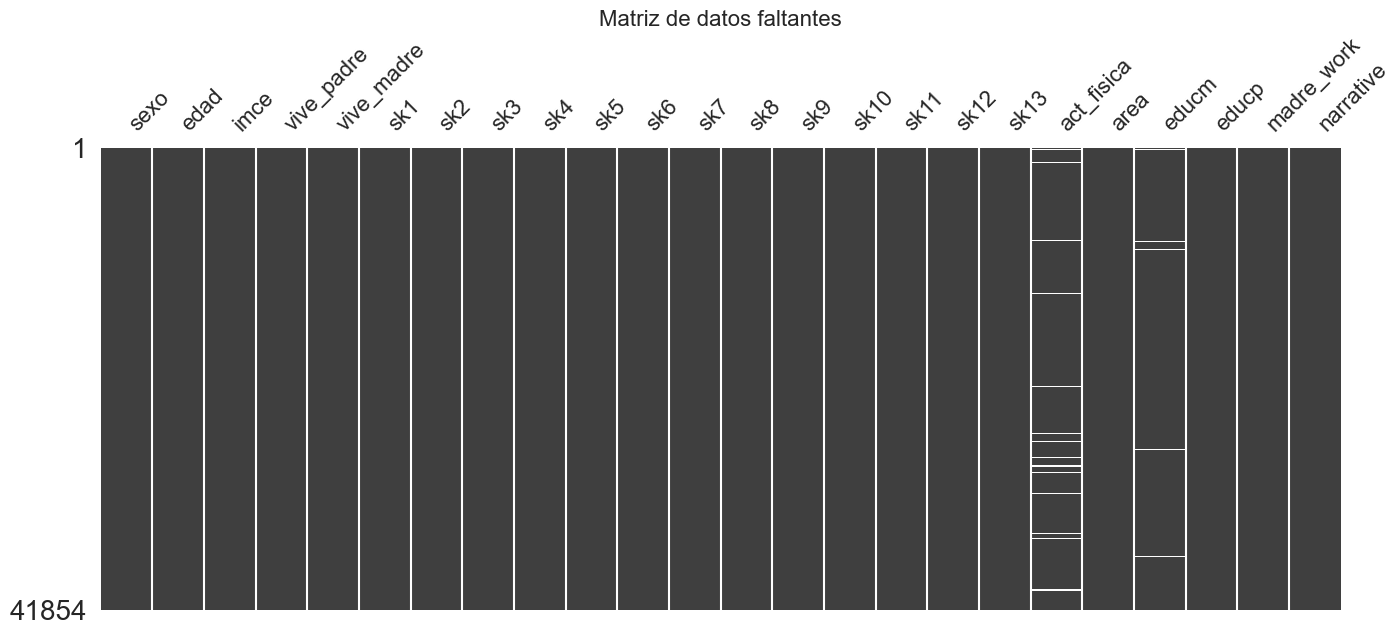

In [4]:
# Conteo exacto de nulos por variable
nulos = df.isnull().sum()
print("Valores faltantes por variable:")
print(nulos[nulos > 0])
print("\nTotal de valores faltantes:", df.isnull().sum().sum())

# Matriz de nulos
msn.matrix(df, figsize=(16, 6), sparkline=False)
plt.title('Matriz de datos faltantes', fontsize=16)
plt.show()

Solo dos variables presentan valores faltantes: "act_fisica" (1.435 nulos, 3,4% de la muestra) y "educm" (551 nulos, 1,3%). La proporción es baja y la matriz no revela un patrón de bloques sistemático, por lo que se procederá con imputación por mediana.

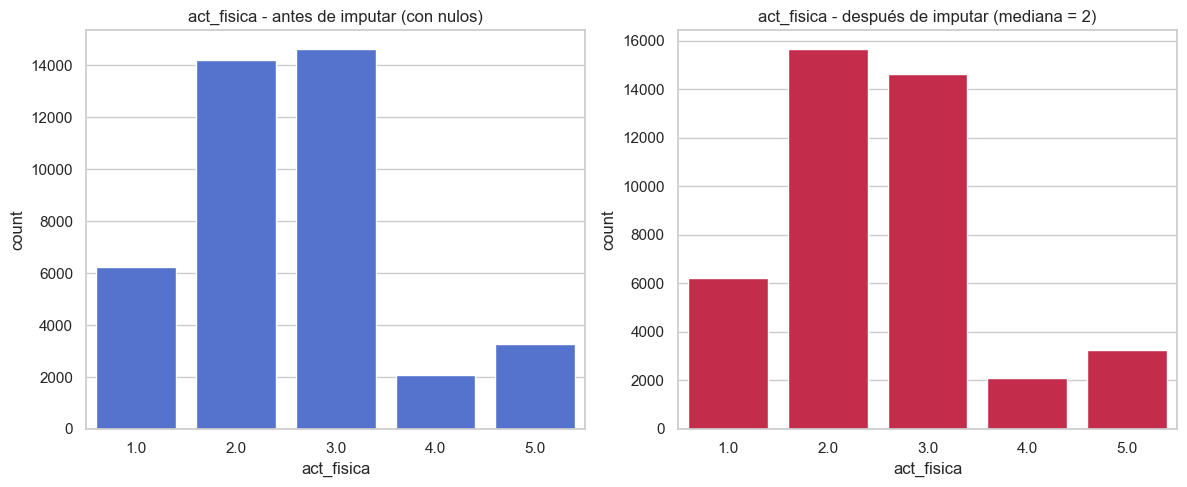

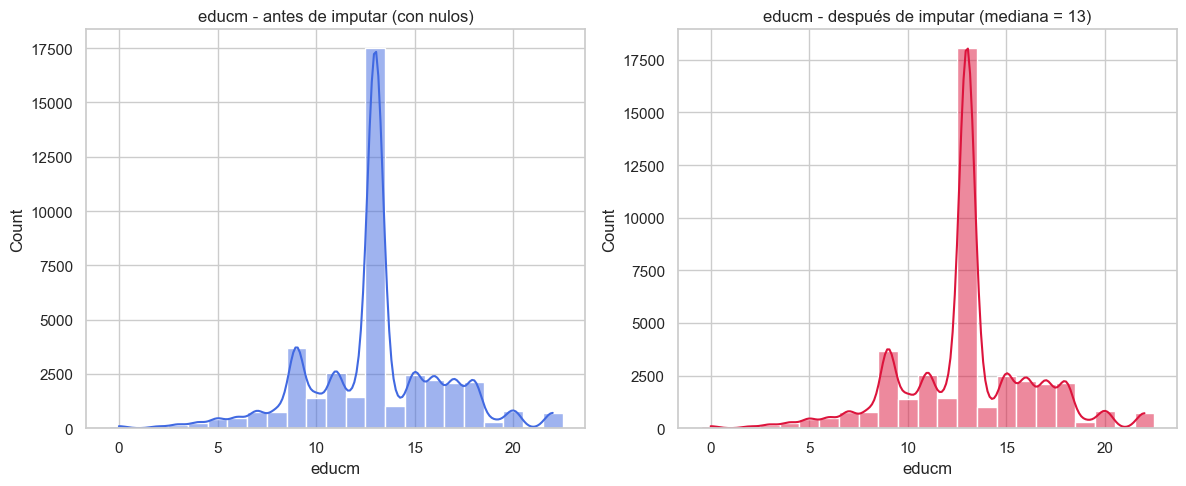

In [5]:
# Comparación de las distribuciones antes y después de imputar con la mediana.
# La imputación se hace sobre una copia para no modificar df todavía.
df_imputed = df.copy()
df_imputed['act_fisica'] = df_imputed['act_fisica'].fillna(df_imputed['act_fisica'].median())
df_imputed['educm'] = df_imputed['educm'].fillna(df_imputed['educm'].median())

# act_fisica (ordinal)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='act_fisica', ax=axes[0], color='royalblue')
axes[0].set_title('act_fisica - antes de imputar (con nulos)')
sns.countplot(data=df_imputed, x='act_fisica', ax=axes[1], color='crimson')
axes[1].set_title('act_fisica - después de imputar (mediana = 2)')
plt.tight_layout(); plt.show()

# educm (discreta)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['educm'].dropna(), kde=True, ax=axes[0], color='royalblue', bins=15, discrete=True)
axes[0].set_title('educm - antes de imputar (con nulos)')
sns.histplot(df_imputed['educm'], kde=True, ax=axes[1], color='crimson', bins=15, discrete=True)
axes[1].set_title('educm - después de imputar (mediana = 13)')
plt.tight_layout(); plt.show()

### Impacto de la imputación por la mediana

Al contrastar las distribuciones antes y después de imputar los valores faltantes se observa lo siguiente:

- Escolaridad de la madre ("educm"): dado el bajo porcentaje de nulos (~1,3%), imputar con la mediana (13 años) refuerza levemente esa categoría, pero no altera la forma general de la distribución.
- Actividad física ("act_fisica"): originalmente las categorías 2 y 3 tenían frecuencias casi iguales, con la 3 como moda. Al imputar los nulos (3,4%) con la mediana (valor 2), esos casos se suman a la categoría 2.

En ambos casos la proporción imputada es baja, así que el sesgo introducido es menor.

### Distribución de variables continuas y detección de outliers

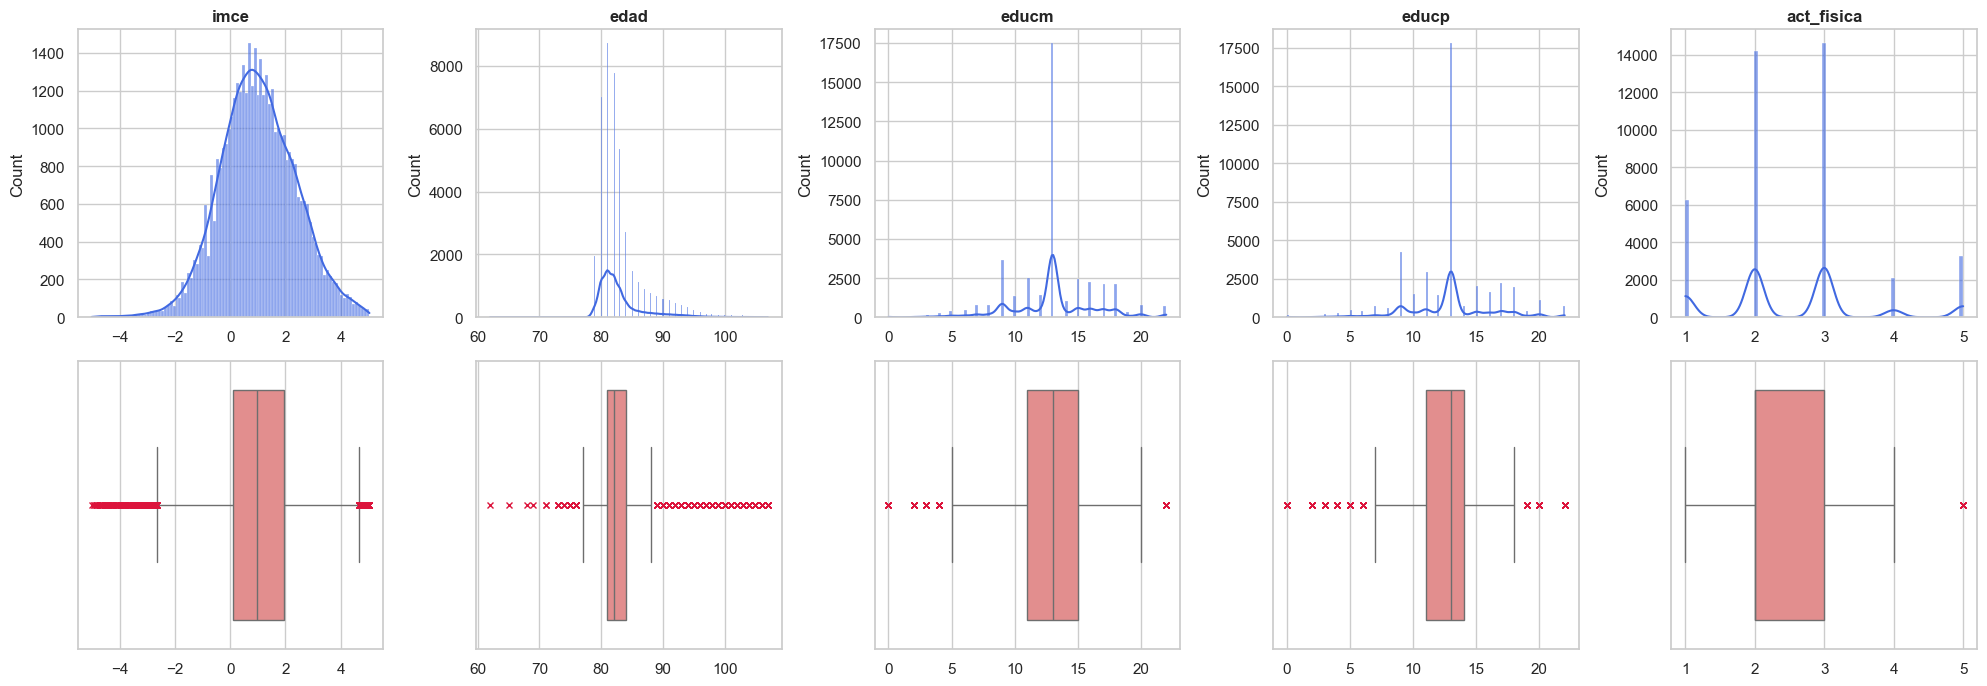

In [6]:
# Histogramas + boxplots para variables continuas y act_fisica
vars_dist = ['imce', 'edad', 'educm', 'educp', 'act_fisica']
fig, axes = plt.subplots(2, len(vars_dist), figsize=(20, 7))
for i, col in enumerate(vars_dist):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color='royalblue', edgecolor='white', alpha=0.6)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_xlabel('')
    sns.boxplot(x=df[col].dropna(), ax=axes[1, i], color='lightcoral',
                flierprops={"marker": "x", "markeredgecolor": "crimson", "markersize": 4})
    axes[1, i].set_xlabel('')
plt.tight_layout()
plt.show()

**Análisis de distribuciones y outliers.**

- "imce" (IMC estandarizado) se distribuye de forma aproximadamente simétrica en torno a ~1 desviación, con colas que llegan a $\pm 5$ desviaciones estándar. Estos extremos son valores plausibles del puntaje z (no errores de medición), por lo que se conservan: representan casos reales de desnutrición y obesidad que son relevantes.
- "edad" (en meses) se concentra entre los 80 y 84 meses, con algunos valores hasta 107 meses (~9 años). Son colas de estudiantes mayores y se mantienen.
- "educm" y "educp" (años de escolaridad de los padres) muestran la mezcla esperada de niveles educativos, con un mínimo en 0 (sin escolaridad formal).
- "act_fisica" es una variable ordinal discreta (1-5); su boxplot solo confirma que la mediana se ubica en torno a 2-3 sesiones semanales.

Se decide no eliminar outliers: en variables como "imce" los extremos son precisamente la información de interés, y removerlos sesgaría el análisis nutricional posterior (Pregunta 6).

### Comportamiento de las variables categóricas

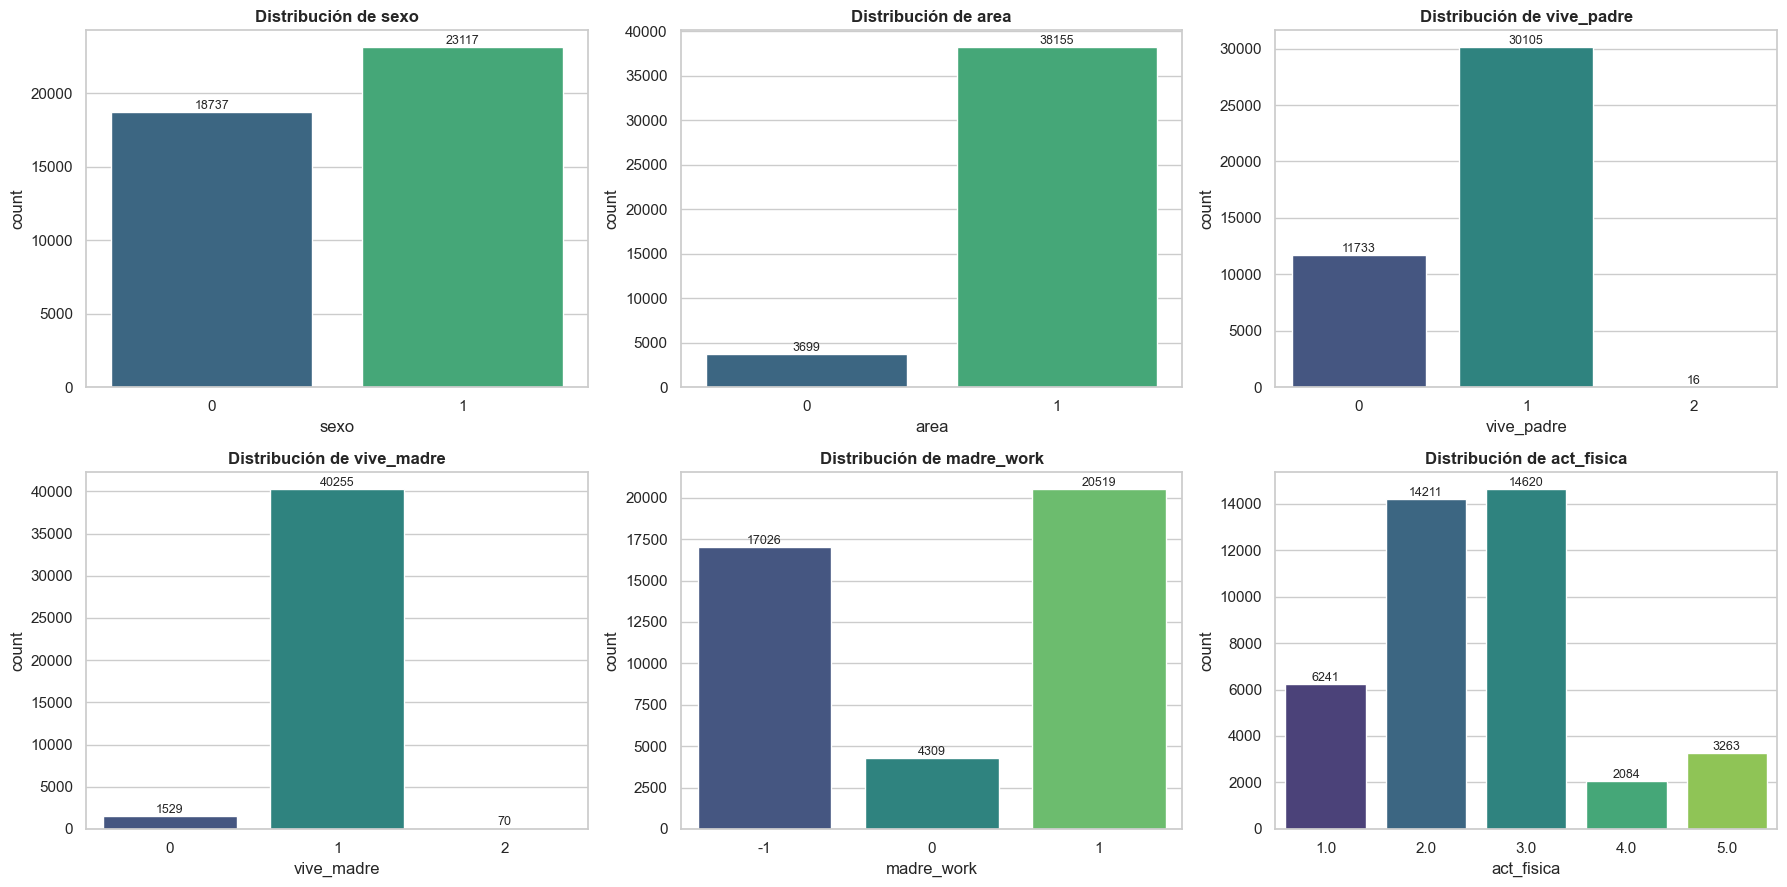

In [7]:
# Distribución de las variables categóricas / discretas
cat_vars = ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work', 'act_fisica']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_vars):
    ax = sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Análisis de las categóricas.**

- "sexo" y "area" están razonablemente distribuidas.
- "vive_padre" y "vive_madre" presentan una categoría "2" extremadamente minoritaria. Según el diccionario, el "2" indica "más de un padre/madre en el hogar". Además, se detecta una inconsistencia en el diccionario: declara "vive_madre = 2" como "vive en el hogar", pero los datos muestran que el código dominante es "1" (40.255 casos), análogo a "vive_padre = 1". Interpretaremos por tanto "1" = progenitor presente. Para evitar una categoría residual inestable, recodificaremos "2 a 1" (al menos un progenitor presente), dejando la variable como binaria presente / ausente.
- "madre_work" es la variable objetivo de la clasificación: empleada (1) = 20.519, labor doméstica (-1) = 17.026 y desempleada (0) = 4.309. Tal como indica el enunciado, la categoría desempleada es minoritaria.

### Tratamiento de valores faltantes y recodificación

Las decisiones de limpieza, debidamente justificadas, son las siguientes:

1. "act_fisica" (ordinal, 1.435 nulos): se imputa con la mediana.
2. "educm" (continua, 551 nulos): se imputa con la mediana.
3. "vive_padre" / "vive_madre": se recodifica "2 a 1" para consolidar la categoría residual y obtener un indicador binario de presencia del progenitor.
4. Se verifica la ausencia de filas duplicadas.

In [8]:
# 1-2. Imputación por mediana
df['act_fisica'] = df['act_fisica'].fillna(df['act_fisica'].median())
df['educm'] = df['educm'].fillna(df['educm'].median())

# 3. Recodificación de la categoría residual "2" en presencia de progenitores
df['vive_padre'] = df['vive_padre'].replace({2: 1})
df['vive_madre'] = df['vive_madre'].replace({2: 1})

# 4. Duplicados y verificación final
print("Filas duplicadas:", df.duplicated().sum())
print("Valores faltantes restantes:", df.isnull().sum().sum())
print("Categorías vive_padre:", sorted(df['vive_padre'].unique()),
      "| vive_madre:", sorted(df['vive_madre'].unique()))

Filas duplicadas: 0
Valores faltantes restantes: 0
Categorías vive_padre: [0, 1] | vive_madre: [0, 1]


### Estadísticas descriptivas finales y correlaciones

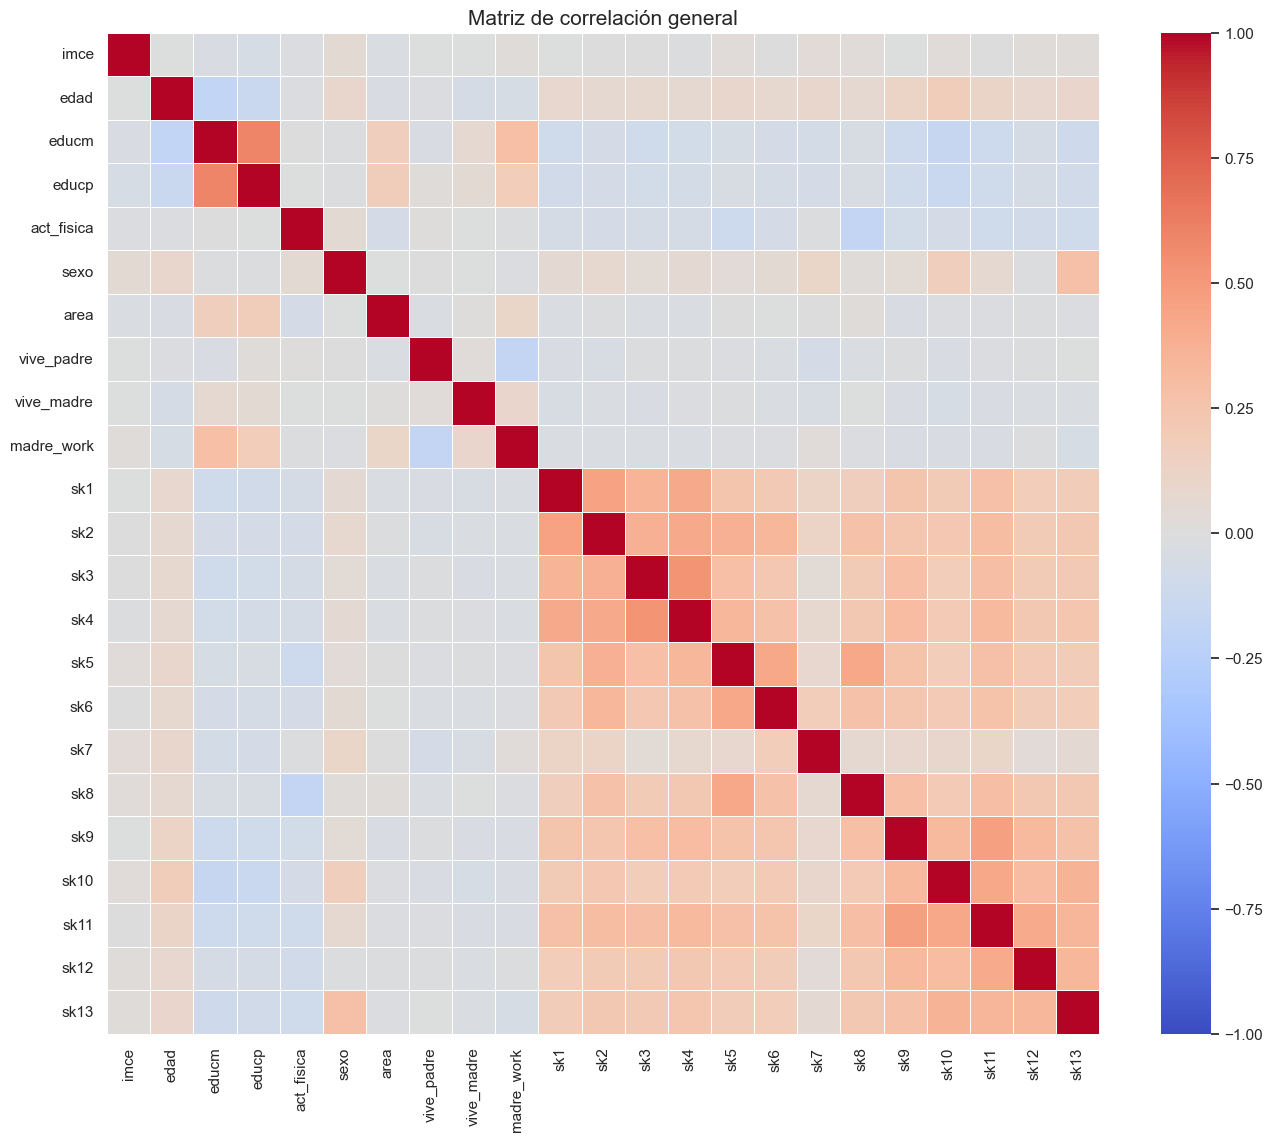

In [9]:
# Mapa de calor de correlaciones (variables numéricas relevantes)
num_cols = ['imce', 'edad', 'educm', 'educp', 'act_fisica', 'sexo', 'area',
            'vive_padre', 'vive_madre', 'madre_work'] + sks
plt.figure(figsize=(16, 13))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4)
plt.title('Matriz de correlación general', fontsize=15)
plt.show()

El mapa de calor muestra que los ítems "sk1"-"sk13" forman un bloque intercorrelacionado entre sí (cuadrante inferior derecho), mientras que su correlación con el entorno familiar ("educm", "educp", "madre_work") es débil. Esto anticipa que los ítems socioemocionales comparten varianza latente común, explotable mediante análisis factorial.

## Pregunta 2: Análisis Factorial Exploratorio (EFA)

A partir de los ítems "sk1"-"sk13" realizamos un EFA para determinar el número óptimo de factores latentes, reportar las variables asociadas a cada factor mediante los factor loadings y discutir la existencia de variables no informativas.

El enunciado pide que todas las variables apunten en el mismo sentido positivo, así que conviene revisar la codificación con cuidado:

- Los ítems "sk1"-"sk6" y "sk8"-"sk13" describen conductas positivas con anclas "1 = siempre … 5 = nunca"; un puntaje bajo indica más competencia.
- El ítem "sk7" ("es agresivo") es el único redactado en sentido negativo, pero con anclas invertidas ("1 = nunca … 5 = siempre"); un puntaje bajo también indica más competencia (nunca agresivo).

Es decir, como sus anclas están invertidas, "sk7" ya queda alineado con el resto en la escala cruda (en todos, "1 = deseable"). Lo confirmamos empíricamente: si "sk7" apuntara en sentido opuesto, correlacionaría negativamente con los demás. Para dejar todos los ítems como aspectos positivos (más alto = mejor), aplicamos la misma transformación $6 - x$ a los trece ítems. El error a evitar es invertir solo "sk7", lo que lo descolocaría del resto.

In [10]:
# Verificación empírica: ¿sk7 ya está alineado con el resto en la escala cruda?
corr_sk7 = df[sks].corr()['sk7'].drop('sk7')
print("Correlación de sk7 (crudo) con los demás ítems:")
print(corr_sk7.round(3))
print(f"\nTodas positivas: {(corr_sk7 > 0).all()}  ->  sk7 ya apunta en el mismo sentido (anclas invertidas)")

# Recodificación uniforme: 6 - item (ahora 5 = conducta más positiva)
sks_pos = [f'{s}_pos' for s in sks]
for s in sks:
    df[f'{s}_pos'] = 6 - df[s]

# Consistencia interna (alfa de Cronbach)
def cronbach_alpha(X):
    X = np.asarray(X, dtype=float)
    k = X.shape[1]
    return (k / (k - 1)) * (1 - X.var(axis=0, ddof=1).sum() / X.sum(axis=1).var(ddof=1))

print(f"\nAlfa de Cronbach (13 ítems recodificados): {cronbach_alpha(df[sks_pos].values):.4f}")

Correlación de sk7 (crudo) con los demás ítems:
sk1    0.121
sk2    0.124
sk3    0.041
sk4    0.072
sk5    0.084
sk6    0.187
sk8    0.064
sk9    0.082
sk10   0.088
sk11   0.106
sk12   0.038
sk13   0.055
Name: sk7, dtype: float64

Todas positivas: True  ->  sk7 ya apunta en el mismo sentido (anclas invertidas)

Alfa de Cronbach (13 ítems recodificados): 0.7792


La correlación de "sk7" con todos los demás ítems es positiva (entre 0,04 y 0,19), lo que confirma que, gracias a sus anclas invertidas, ya estaba en el mismo sentido lógico.

### Adecuación muestral: test de esfericidad de Bartlett y KMO

In [11]:
chi2_b, p_b = calculate_bartlett_sphericity(df[sks_pos])
kmo_items, kmo_model = calculate_kmo(df[sks_pos])
print(f"Test de esfericidad de Bartlett:  chi2 = {chi2_b:.1f},  p-value = {p_b:.3g}")
print(f"KMO global (Kaiser-Meyer-Olkin): {kmo_model:.4f}")
print("\nKMO por ítem:")
print(pd.Series(kmo_items, index=sks_pos).round(3))

Test de esfericidad de Bartlett:  chi2 = 122116.7,  p-value = 0
KMO global (Kaiser-Meyer-Olkin): 0.8732

KMO por ítem:
sk1_pos    0.870
sk2_pos    0.881
sk3_pos    0.861
sk4_pos    0.859
sk5_pos    0.845
sk6_pos    0.875
sk7_pos    0.788
sk8_pos    0.873
sk9_pos    0.898
sk10_pos   0.879
sk11_pos   0.876
sk12_pos   0.895
sk13_pos   0.894
dtype: float64


Ambos contrastes validan la pertinencia del análisis factorial:

- Bartlett: $\chi^2 \approx 122.117$, $p < 0{,}001$. Se rechaza la hipótesis nula de que la matriz de correlaciones es una identidad; existen correlaciones suficientes para factorizar.
- KMO global = 0,873 ("meritorio" según Kaiser). Todos los ítems superan individualmente 0,78, por lo que ninguno debe descartarse por inadecuación muestral.

### Determinación del número óptimo de factores

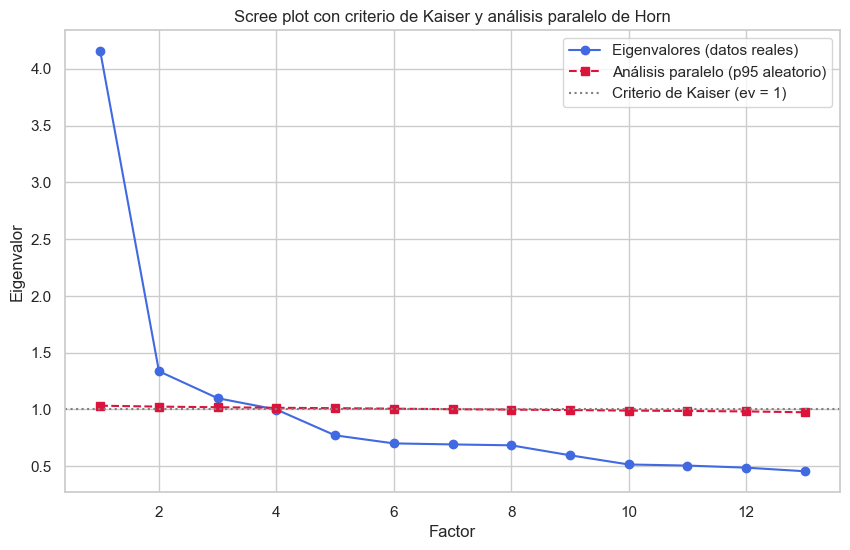

Número de factores - Kaiser (ev>1): 3
Número de factores - Análisis paralelo (ev_real > ev_aleatorio): 3


In [12]:
# Eigenvalores, criterio de Kaiser, scree plot y análisis paralelo de Horn
fa_full = FactorAnalyzer(n_factors=13, rotation=None)
fa_full.fit(df[sks_pos])
eigenvalues, _ = fa_full.get_eigenvalues()

def parallel_analysis(X, n_iter=20, percentile=95, seed=RANDOM_STATE):
    n, k = X.shape
    rng = np.random.default_rng(seed)
    rand_ev = []
    for _ in range(n_iter):
        Xr = np.column_stack([rng.permutation(X[:, j]) for j in range(k)])
        f = FactorAnalyzer(n_factors=k, rotation=None); f.fit(Xr)
        rand_ev.append(f.get_eigenvalues()[0])
    return np.percentile(np.array(rand_ev), percentile, axis=0)

pa_ev = parallel_analysis(df[sks_pos].values, n_iter=15)
n_kaiser = int((eigenvalues > 1).sum())
n_parallel = int((eigenvalues > pa_ev).sum())

plt.figure(figsize=(10, 6))
plt.plot(range(1, 14), eigenvalues, 'o-', color='royalblue', label='Eigenvalores (datos reales)')
plt.plot(range(1, 14), pa_ev, 's--', color='crimson', label='Análisis paralelo (p95 aleatorio)')
plt.axhline(1, color='gray', linestyle=':', label='Criterio de Kaiser (ev = 1)')
plt.xlabel('Factor'); plt.ylabel('Eigenvalor')
plt.title('Scree plot con criterio de Kaiser y análisis paralelo de Horn')
plt.legend(); plt.show()

print(f"Número de factores - Kaiser (ev>1): {n_kaiser}")
print(f"Número de factores - Análisis paralelo (ev_real > ev_aleatorio): {n_parallel}")

Los criterios convergen en la misma solución: 3 factores.

- Criterio de Kaiser: 3 eigenvalores superan la unidad (4,15; 1,34; 1,10).
- Scree plot: el "codo" se produce tras el tercer factor.
- Análisis paralelo de Horn: solo los 3 primeros eigenvalores reales superan a los de los datos aleatorios.

Adoptamos 3 factores.

### Estimación del EFA y factor loadings

Factor loadings (rotación promax) y comunalidades:


,F1,F2,F3,comunalidad,factor_asignado
sk1_pos (afecto a padres),0.025,0.617,-0.040,0.382,F2
sk2_pos (afecto a pares),-0.040,0.506,0.231,0.311,F2
sk3_pos (expresa sentimientos),0.022,0.666,-0.046,0.446,F2
sk4_pos (gestos afectivos),-0.000,0.750,-0.028,0.564,F2
sk5_pos (juega con otros),-0.159,-0.022,0.878,0.797,F3
sk6_pos (comparte cosas),0.007,0.051,0.520,0.273,F3
sk7_pos (NO agresivo (inv.)),0.023,0.033,0.136,0.020,F3
sk8_pos (juegos grupales),0.147,-0.106,0.519,0.303,F3
sk9_pos (pregunta a adultos),0.495,0.085,0.056,0.256,F1
sk10_pos (interés por libros),0.624,-0.032,-0.031,0.392,F1



Varianza explicada por factor:


,SS loadings,Prop. varianza,Var. acumulada
F1,1.800,0.138,0.138
F2,1.670,0.128,0.267
F3,1.392,0.107,0.374



Correlación entre factores (matriz phi):


,F1,F2,F3
F1,1.000,0.576,0.648
F2,0.576,1.000,0.612
F3,0.648,0.612,1.000


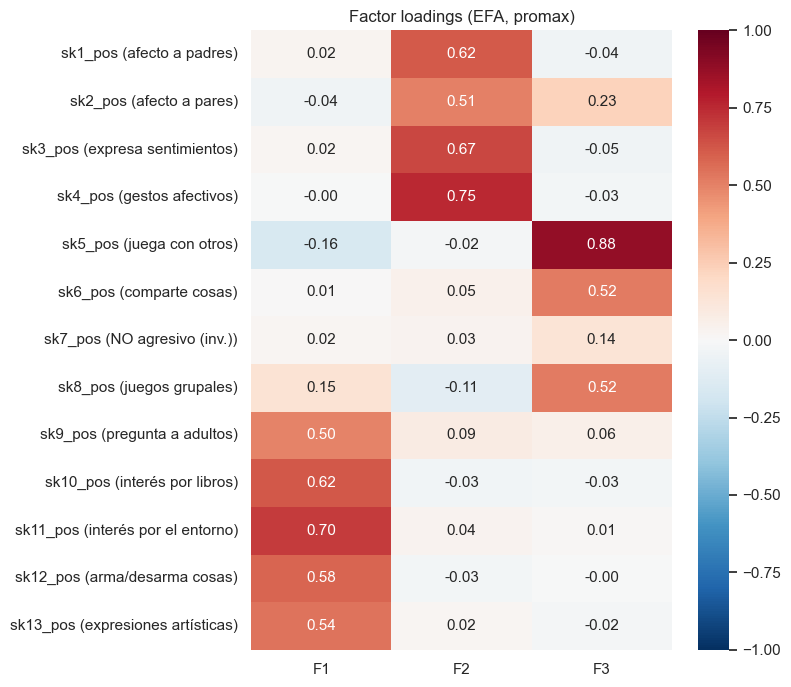

In [13]:
# EFA con 3 factores y rotación oblicua (promax), pues se espera correlación entre dimensiones
etiquetas = {'sk1': 'afecto a padres', 'sk2': 'afecto a pares', 'sk3': 'expresa sentimientos',
             'sk4': 'gestos afectivos', 'sk5': 'juega con otros', 'sk6': 'comparte cosas',
             'sk7': 'NO agresivo (inv.)', 'sk8': 'juegos grupales', 'sk9': 'pregunta a adultos',
             'sk10': 'interés por libros', 'sk11': 'interés por el entorno', 'sk12': 'arma/desarma cosas',
             'sk13': 'expresiones artísticas'}

fa = FactorAnalyzer(n_factors=3, rotation='promax')
fa.fit(df[sks_pos])

idx = [f"{s} ({etiquetas[s.replace('_pos','')]})" for s in sks_pos]
loadings = pd.DataFrame(fa.loadings_, index=idx, columns=['F1', 'F2', 'F3'])
loadings['comunalidad'] = fa.get_communalities()
loadings['factor_asignado'] = loadings[['F1', 'F2', 'F3']].abs().idxmax(axis=1)
print("Factor loadings (rotación promax) y comunalidades:")
display(loadings.round(3))

var = fa.get_factor_variance()
print("\nVarianza explicada por factor:")
display(pd.DataFrame({'SS loadings': var[0], 'Prop. varianza': var[1], 'Var. acumulada': var[2]},
                     index=['F1', 'F2', 'F3']).round(3))
print("\nCorrelación entre factores (matriz phi):")
display(pd.DataFrame(fa.phi_, index=['F1', 'F2', 'F3'], columns=['F1', 'F2', 'F3']).round(3))

# Heatmap de loadings
plt.figure(figsize=(8, 7))
sns.heatmap(loadings[['F1', 'F2', 'F3']], annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Factor loadings (EFA, promax)')
plt.tight_layout(); plt.show()

Interpretación de los loadings. La rotación oblicua produce una estructura simple con tres dimensiones interpretables:

| Factor | Ítems con carga dominante | Concepto latente |
|--------|---------------------------|------------------|
| F1 | "sk9", "sk10", "sk11", "sk12", "sk13" (preguntas, libros, entorno, armar/desarmar, arte) | Curiosidad, exploración e interés |
| F2 | "sk1", "sk2", "sk3", "sk4" (afecto a padres/pares, expresión y gestos de sentimientos) | Expresión afectivo-emocional |
| F3 | "sk5", "sk6", "sk8" (juega con otros, comparte, juegos grupales) | Interacción social |

La matriz de correlaciones entre factores muestra que están moderada a fuertemente correlacionados, lo que respalda la elección de una rotación oblicua frente a una ortogonal.

Variable no informativa. El ítem "sk7" ("es agresivo") no aporta información: su comunalidad es de apenas 0,02 (el modelo de 3 factores explica solo un 2% de su varianza) y su mayor carga es de 0,14. Tiene sentido, la agresividad es una conducta externalizante que opera de forma casi independiente de las habilidades pro-sociales y cognitivas que miden el resto de los ítems. El ítem "sk2" presenta una carga cruzada menor (0,51 en F2 y 0,23 en F3), pero su comunalidad es adecuada y se asigna a F2 por carga dominante. Por eso "sk7" se excluye del modelo confirmatorio de la Pregunta 3.

## Pregunta 3: Análisis Factorial Confirmatorio (CFA)

Con la estructura sugerida por el EFA, especificamos un CFA en el que cada variable se asocia a un único factor. Excluimos "sk7" por no informativo. Estimamos el modelo con "semopy" (máxima verosimilitud), reportamos la importancia de cada medida (loadings estandarizados), la correlación entre factores y los índices de ajuste, y finalmente guardamos las predicciones (factor scores).

In [14]:
# Especificación del modelo de medición (cada ítem -> un solo factor)
modelo_cfa = '''
Cognitivo =~ sk9_pos + sk10_pos + sk11_pos + sk12_pos + sk13_pos
Afectivo  =~ sk1_pos + sk2_pos + sk3_pos + sk4_pos
Social    =~ sk5_pos + sk6_pos + sk8_pos
'''
#notar que sk7 fue excluido
cfa = semopy.Model(modelo_cfa)
res_opt = cfa.fit(df)
print(res_opt)

# Estimaciones estandarizadas
ins = cfa.inspect(std_est=True)
loadings_cfa = ins[ins['op'] == '~'][['lval', 'rval', 'Estimate', 'Est. Std', 'p-value']]
loadings_cfa.columns = ['Ítem', 'Factor', 'Carga', 'Carga estand.', 'p-value']
print("\nFactor loadings del CFA (importancia de cada medida):")
display(loadings_cfa.round(3).reset_index(drop=True))

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.147
Number of iterations: 42
Params: 1.306 1.215 1.077 1.265 1.793 1.596 1.751 1.027 1.139 0.058 0.172 0.061 0.173 0.066 0.103 0.626 0.214 0.459 0.730 0.103 0.252 0.206 0.169 0.158 0.375 0.492 0.294

Factor loadings del CFA (importancia de cada medida):


,Ítem,Factor,Carga,Carga estand.,p-value
0,sk9_pos,Cognitivo,1.000,0.608,-
1,sk10_pos,Cognitivo,1.306,0.565,0.000
2,sk11_pos,Cognitivo,1.215,0.736,0.000
3,sk12_pos,Cognitivo,1.077,0.551,0.000
4,sk13_pos,Cognitivo,1.265,0.523,0.000
5,sk1_pos,Afectivo,1.000,0.600,-
6,sk2_pos,Afectivo,1.793,0.652,0.000
7,sk3_pos,Afectivo,1.596,0.646,0.000
8,sk4_pos,Afectivo,1.751,0.715,0.000
9,sk5_pos,Social,1.000,0.723,-


In [15]:
# Correlaciones entre factores
factor_names = ['Cognitivo', 'Afectivo', 'Social']
corr_fac = ins[(ins['op'] == '~~') & (ins['lval'] != ins['rval']) &
               (ins['lval'].isin(factor_names)) & (ins['rval'].isin(factor_names))]
print("Correlación entre factores latentes (loadings):")
display(corr_fac[['lval', 'rval', 'Estimate', 'Est. Std', 'p-value']].round(3).reset_index(drop=True))

# Índices de ajuste
stats = semopy.calc_stats(cfa)
print("\nÍndices de ajuste del modelo:")
display(stats[['chi2', 'DoF', 'CFI', 'TLI', 'RMSEA', 'GFI', 'AIC', 'BIC']].T.round(4))

Correlación entre factores latentes (loadings):

,lval,rval,Estimate,Est. Std,p-value
0,Cognitivo,Afectivo,0.061,0.612,0.000
1,Social,Afectivo,0.066,0.658,0.000
2,Social,Cognitivo,0.103,0.596,0.000



Índices de ajuste del modelo:


,Value
chi2,6148.096
DoF,51.000
CFI,0.949
TLI,0.934
RMSEA,0.053
GFI,0.949
AIC,53.706
BIC,287.039


In [16]:
# Predicción de los factor scores y guardado (Guarde sus predicciones)
factor_scores = cfa.predict_factors(df)
df[['Afectivo', 'Cognitivo', 'Social']] = factor_scores[['Afectivo', 'Cognitivo', 'Social']].values
factor_scores.to_csv('factor_scores_cfa.csv', index=False)
print("Factor scores guardados en 'factor_scores_cfa.csv'")
display(df[['Afectivo', 'Cognitivo', 'Social']].describe().T.round(3))

Factor scores guardados en 'factor_scores_cfa.csv'


,count,mean,std,min,25%,50%,75%,max
Afectivo,41854.000,-0.000,0.214,-2.020,-0.066,0.084,0.145,0.160
Cognitivo,41854.000,-0.000,0.367,-2.767,-0.179,0.112,0.275,0.353
Social,41854.000,0.000,0.356,-3.001,-0.151,0.126,0.269,0.308


**Interpretación del CFA.**

- Importancia de las medidas (loadings estandarizados). Todas las cargas son positivas y altamente significativas ($p < 0{,}001$). Dentro de cada factor, los indicadores con mayor peso son "sk4" (gestos afectivos) en Afectivo, "sk11" (interés por el entorno) en Cognitivo y "sk5" (juega con otros) en Social, que actúan como los marcadores más representativos de cada constructo.
- Correlación entre factores. Las dimensiones latentes están fuertemente correlacionadas (Afectivo-Social $\approx$ 0,66; Afectivo-Cognitivo $\approx$ 0,61; Cognitivo-Social $\approx$ 0,60), consistente con la idea de un desarrollo socioemocional global del que emergen tres facetas diferenciables.
- Ajuste del modelo. Los índices son buenos: CFI = 0,949 y TLI = 0,934, RMSEA = 0,053 y GFI = 0,949. El $\chi^2$ resulta significativo, algo esperable con $n \approx 41.800$, donde el test es hipersensible, por ello priorizamos los índices incrementales y de aproximación, que avalan la estructura de tres factores.
- Predicciones. Se asignó a cada estudiante su puntaje en los tres factores latentes ("Afectivo", "Cognitivo", "Social"). Estos factor scores son los features que alimentarán los modelos de clasificación de las Preguntas 4, 5 y 7.

### Diagrama de senderos del CFA

Para visualizar el modelo confirmatorio graficamos su diagrama de senderos, con las cargas estandarizadas de cada ítem sobre su factor y las correlaciones entre los tres factores latentes.

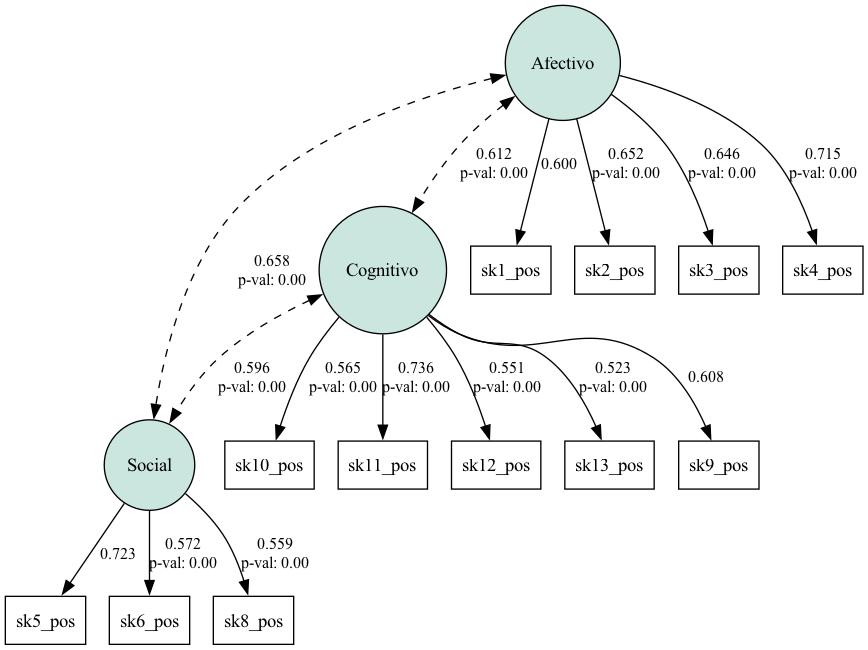

In [17]:
# Diagrama de senderos del CFA: cargas estandarizadas y correlaciones entre factores.
# semplot requiere tener Graphviz instalado en el sistema (binario 'dot').
from IPython.display import Image
try:
    semopy.semplot(cfa, 'diagrama_cfa.png', plot_ests=True, std_ests=True, plot_covs=True)
    display(Image(filename='diagrama_cfa.png'))
except Exception as e:
    print('No se pudo generar el diagrama (se requiere Graphviz en el sistema):', e)

## Pregunta 4: Clasificación del empleo materno con Random Forest

Usando como features los tres factor scores del CFA, entrenamos un modelo Random Forest para clasificar "madre_work". Tal como indica el enunciado, excluimos la categoría desempleada (0), la minoritaria, dejando un problema binario: empleada (1) vs. labor doméstica (-1). Incorporamos optimización de hiperparámetros ("GridSearchCV") y validación cruzada con pliegues (k-fold).

In [18]:
# Construcción de la muestra de clasificación (se excluye desempleada = 0)
features = ['Afectivo', 'Cognitivo', 'Social']
df_clf = df[df['madre_work'] != 0].copy()
y = (df_clf['madre_work'] == 1).astype(int).values   # 1 = empleada, 0 = labor doméstica
X = df_clf[features].values

baseline = np.bincount(y).max() / len(y)
print("Muestra de clasificación:", X.shape)
print("Distribución de clases:", dict(zip(*np.unique(y, return_counts=True))))
print(f"Baseline (clasificador mayoritario): {baseline:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

Muestra de clasificación: (37545, 3)
Distribución de clases: {0: 17026, 1: 20519}
Baseline (clasificador mayoritario): 0.5465


In [19]:
# Optimización de hiperparámetros con validación cruzada estratificada (k-fold)
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [1, 20, 50],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Accuracy media en CV (k=5): {grid_rf.best_score_:.4f}")

# Validación k-fold adicional del mejor estimador (RepeatedStratifiedKFold)
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_scores = cross_val_score(grid_rf.best_estimator_, X_train, y_train, cv=rkf, scoring='accuracy', n_jobs=-1)
print(f"Validación repetida (5x3): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 50, 'n_estimators': 200}
Accuracy media en CV (k=5): 0.5518


Validación repetida (5x3): 0.5509 +/- 0.0028


Accuracy en test: 0.5521  (baseline 0.5465)

Reporte de clasificación:
                 precision    recall  f1-score   support

labor doméstica       0.56      0.06      0.11      3405
       empleada       0.55      0.96      0.70      4104

       accuracy                           0.55      7509
      macro avg       0.55      0.51      0.40      7509
   weighted avg       0.55      0.55      0.43      7509



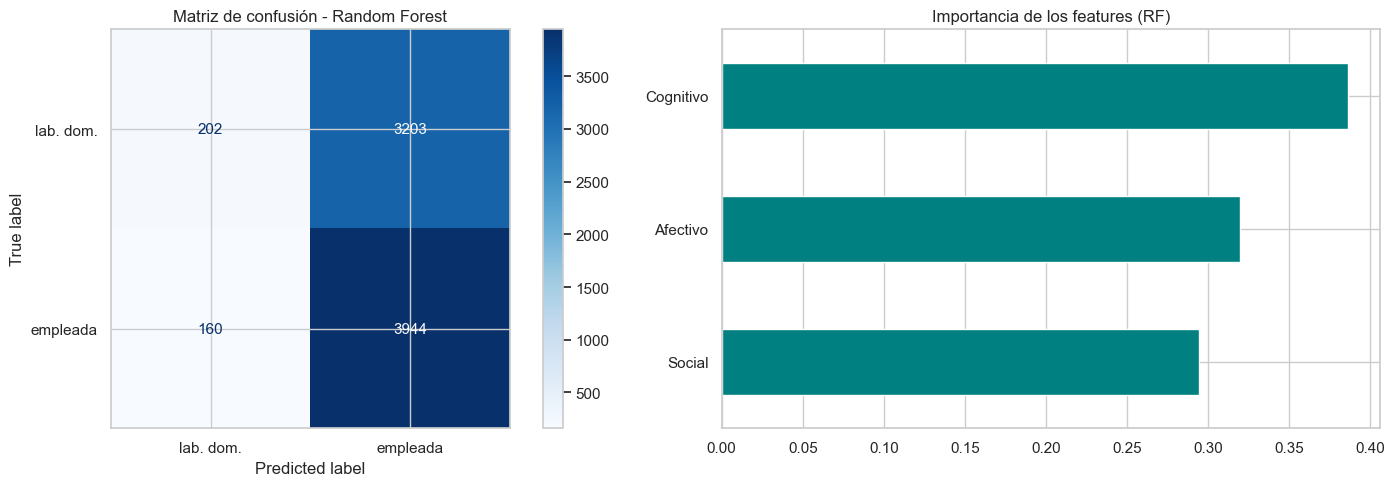

In [20]:
# Evaluación en el conjunto de prueba
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_rf):.4f}  (baseline {baseline:.4f})")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['labor doméstica', 'empleada']))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['lab. dom.', 'empleada'],
                                        cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusión - Random Forest')
imp = pd.Series(rf_best.feature_importances_, index=features).sort_values()
imp.plot.barh(ax=axes[1], color='teal')
axes[1].set_title('Importancia de los features (RF)')
plt.tight_layout(); plt.show()

**Interpretación.** El Random Forest optimizado alcanza una accuracy en test de ~0,55, apenas por encima del baseline mayoritario (0,546). La validación repetida (5×3) confirma la estabilidad de esta cifra con una desviación mínima (±0,003). Entre los hiperparámetros ganadores destaca un "min_samples_leaf" alto y una profundidad acotada, que el propio "GridSearchCV" elige para regularizar y evitar el sobreajuste a una señal débil.

El reporte de clasificación muestra que el modelo acierta sobre todo en la clase mayoritaria (empleada) y tiene baja sensibilidad sobre "labor doméstica". La importancia de features reparte el peso de forma relativamente pareja entre las tres dimensiones. La conclusión es clara: las habilidades socioemocionales del niño contienen muy poca información sobre el tipo de empleo de la madre, algo coherente con la débil correlación detectada en la Pregunta 1.

## Pregunta 5: Comparación con XGBoost, SVM y Stacking

Comparamos el desempeño y la eficiencia computacional de tres enfoques adicionales sobre el mismo problema: XGBoost, Support Vector Machine y Stacking (XGBoost + SVM + RF con meta-modelo logístico). Se mide accuracy, F1 y los tiempos de entrenamiento y predicción, y se contrasta con el Random Forest de la Pregunta 4.

In [21]:
# Definición de los tres modelos. El SVM se encapsula con StandardScaler en pipeline.
modelos = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': make_pipeline(StandardScaler(),
                              SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)),
    'Stacking': StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                  eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
            ('svm', make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE))),
            ('rf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
        ],
        final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1),
}

resultados = {}
for nombre, modelo in modelos.items():
    t0 = time.time(); modelo.fit(X_train, y_train); t_fit = time.time() - t0
    t0 = time.time(); y_pred = modelo.predict(X_test); t_pred = time.time() - t0
    resultados[nombre] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        't_fit': t_fit, 't_pred': t_pred,
        'cm': confusion_matrix(y_test, y_pred),
    }
    print(f"{nombre:12s} | acc={resultados[nombre]['accuracy']:.4f} | f1={resultados[nombre]['f1']:.4f} "
          f"| fit={t_fit:5.1f}s | pred={t_pred:4.2f}s")

# Añadimos el RF de la P4 a la comparación
resultados['Random Forest (P4)'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf), 'f1': f1_score(y_test, y_pred_rf),
    't_fit': np.nan, 't_pred': np.nan, 'cm': confusion_matrix(y_test, y_pred_rf)}

XGBoost      | acc=0.5421 | f1=0.6739 | fit=  0.5s | pred=0.01s


SVM (RBF)    | acc=0.5524 | f1=0.7028 | fit= 12.2s | pred=6.46s


Stacking     | acc=0.5529 | f1=0.7017 | fit= 31.3s | pred=6.68s


Comparación de modelos:


,Accuracy,F1,Tiempo fit (s),Tiempo pred (s)
XGBoost,0.542,0.674,0.503,0.008
SVM (RBF),0.552,0.703,12.237,6.463
Stacking,0.553,0.702,31.260,6.680
Random Forest (P4),0.552,0.701,NaN,NaN


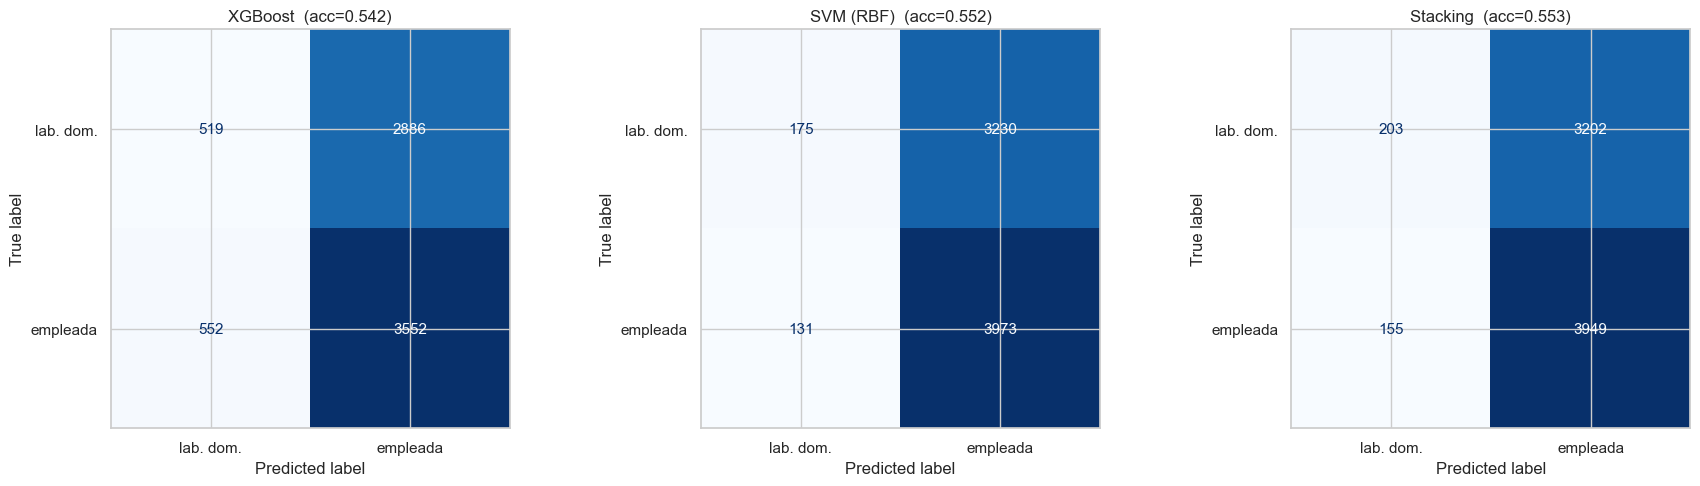

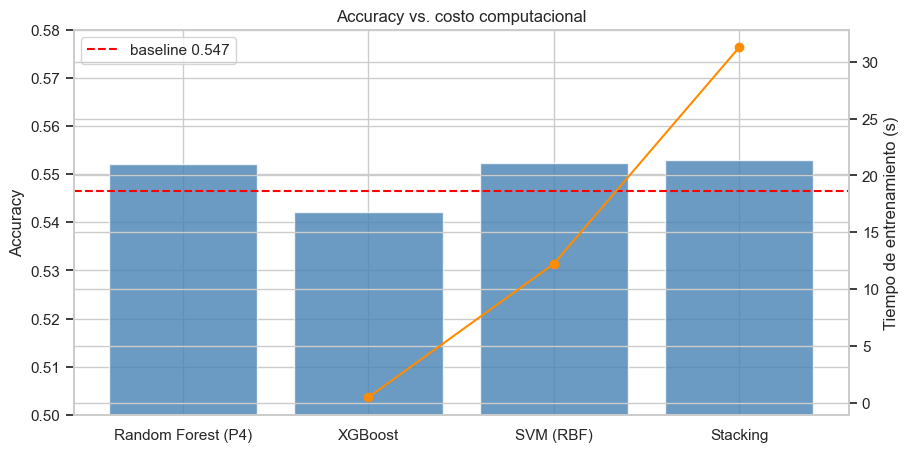

Mejor modelo de la Pregunta 5 (por accuracy): Stacking


In [22]:
# Tabla comparativa
tabla = pd.DataFrame({k: {'Accuracy': v['accuracy'], 'F1': v['f1'],
                          'Tiempo fit (s)': v['t_fit'], 'Tiempo pred (s)': v['t_pred']}
                      for k, v in resultados.items()}).T
print("Comparación de modelos:")
display(tabla.round(4))

# Matrices de confusión de los tres modelos de la P5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nombre in zip(axes, ['XGBoost', 'SVM (RBF)', 'Stacking']):
    ConfusionMatrixDisplay(resultados[nombre]['cm'], display_labels=['lab. dom.', 'empleada']).plot(
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{nombre}  (acc={resultados[nombre]['accuracy']:.3f})")
plt.tight_layout(); plt.show()

# Gráfico de barras: accuracy vs tiempo de entrenamiento
fig, ax1 = plt.subplots(figsize=(10, 5))
orden = ['Random Forest (P4)', 'XGBoost', 'SVM (RBF)', 'Stacking']
ax1.bar(orden, [resultados[m]['accuracy'] for m in orden], color='steelblue', alpha=0.8)
ax1.axhline(baseline, color='red', linestyle='--', label=f'baseline {baseline:.3f}')
ax1.set_ylabel('Accuracy'); ax1.set_ylim(0.5, 0.58); ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(orden, [resultados[m]['t_fit'] for m in orden], 'o-', color='darkorange', label='Tiempo fit (s)')
ax2.set_ylabel('Tiempo de entrenamiento (s)')
plt.title('Accuracy vs. costo computacional'); plt.show()

mejor_p5 = max(['XGBoost', 'SVM (RBF)', 'Stacking'], key=lambda k: resultados[k]['accuracy'])
print("Mejor modelo de la Pregunta 5 (por accuracy):", mejor_p5)

**Discusión.**

Desempeño. Los cuatro modelos quedan en una banda estrecha en torno al baseline (0,546): Stacking lidera con 0,553, seguido por SVM y Random Forest (0,552) y, algo por debajo, XGBoost (0,542). La diferencia entre el mejor y el peor es apenas perceptible, así que en la práctica son equivalentes dada la escasa señal disponible.

Matriz de confusión. El patrón es el mismo en los cuatro: predicen casi siempre la clase mayoritaria (empleada), con muy pocos aciertos en "labor doméstica". El F1 elevado (~0,70) es engañoso, porque proviene de la alta sensibilidad sobre la clase dominante; en la práctica los modelos colapsan al baseline. Esto confirma que los factor scores socioemocionales no separan las clases.

Eficiencia (velocidad de cómputo). Aquí sí hay diferencias grandes (los tiempos dependen del equipo, se reportan los de esta ejecución):
- XGBoost es el más rápido (entrenamiento < 1 s) gracias a su implementación optimizada por histogramas.
- El SVM con kernel RBF es bastante más costoso (~12 s de entrenamiento y ~7 s de predicción), porque su complejidad escala de forma cuadrática-cúbica con las ~30.000 observaciones.
- El Stacking es el más costoso (~40 s), al entrenar internamente los tres modelos base con validación cruzada más el meta-modelo.

Conclusión. Como el desempeño es prácticamente idéntico, XGBoost ofrece la mejor relación costo-beneficio: la misma exactitud que el Stacking a una fracción del tiempo. El mayor costo del Stacking y del SVM no se justifica cuando la señal predictiva es tan débil.

## Pregunta 6: Clustering del estado nutricional y la actividad física

Aplicamos K-Means para generar grupos en base a las variables "imce" (IMC estandarizado) y "act_fisica". Estandarizamos ambas variables (escalas distintas), seleccionamos el número de clusters mediante el método del codo, davies bouldin y coeficientes de silueta, y perfilamos los grupos resultantes.

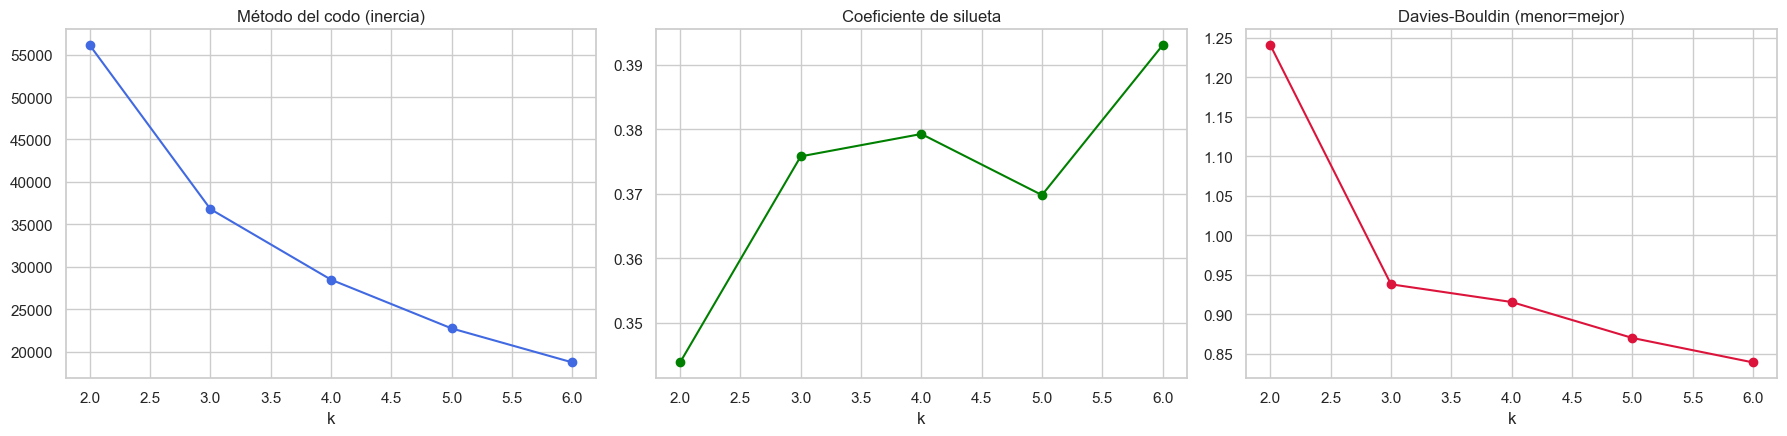

 k   inercia  silueta  davies_bouldin  calinski
 2 56099.000    0.344           1.240 20598.000
 3 36789.000    0.376           0.938 26688.000
 4 28468.000    0.379           0.915 27070.000
 5 22724.000    0.370           0.870 28079.000
 6 18720.000    0.393           0.839 29056.000


In [23]:
# Estandarización de las dos variables
X_clu = StandardScaler().fit_transform(df[['imce', 'act_fisica']])

# Selección de k: codo + métricas internas
ks = range(2, 7)
inercias, siluetas, davies, calinski = [], [], [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_clu)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_clu, km.labels_, sample_size=5000, random_state=RANDOM_STATE))
    davies.append(davies_bouldin_score(X_clu, km.labels_))
    calinski.append(calinski_harabasz_score(X_clu, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(list(ks), inercias, 'o-', color='royalblue'); axes[0].set_title('Método del codo (inercia)')
axes[0].set_xlabel('k')
axes[1].plot(list(ks), siluetas, 'o-', color='green'); axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k')
axes[2].plot(list(ks), davies, 'o-', color='crimson'); axes[2].set_title('Davies-Bouldin (menor=mejor)')
axes[2].set_xlabel('k')
plt.tight_layout(); plt.show()

print(pd.DataFrame({'k': list(ks), 'inercia': np.round(inercias), 'silueta': np.round(siluetas, 3),
                    'davies_bouldin': np.round(davies, 3), 'calinski': np.round(calinski)}).to_string(index=False))

Perfil de los clusters (medias reales):


,imce,act_fisica,n
cluster,,,
0,0.003,2.232,19595
1,2.217,2.239,17026
2,0.886,4.624,5233


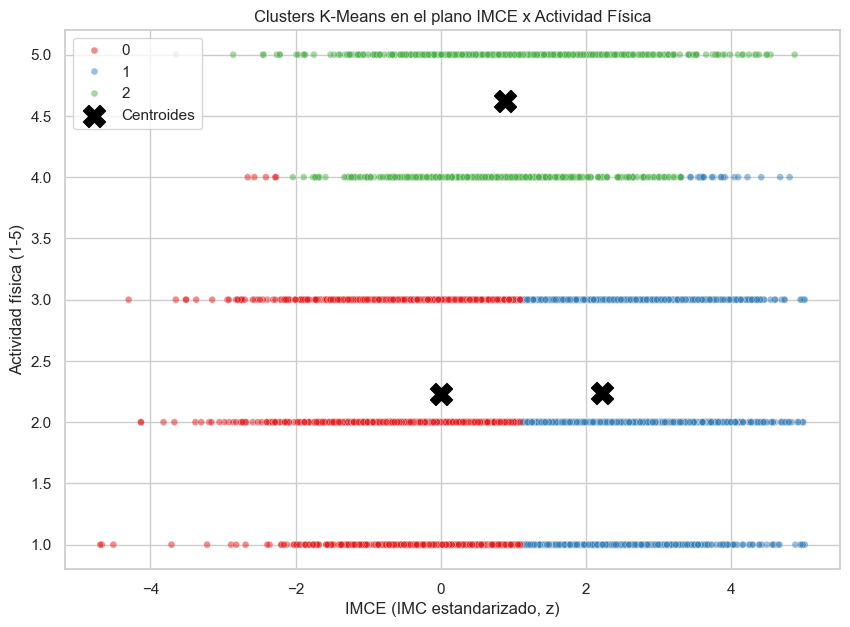

In [24]:
# Solución final con k = 3 (equilibrio entre ajuste e interpretabilidad)
K_OPT = 3
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=10).fit(X_clu)
df['cluster'] = kmeans.labels_

perfil = df.groupby('cluster')[['imce', 'act_fisica']].mean()
perfil['n'] = df['cluster'].value_counts().sort_index()
print("Perfil de los clusters (medias reales):")
display(perfil.round(3))

# Visualización en el plano IMCE x actividad física
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df.sample(8000, random_state=RANDOM_STATE), x='imce', y='act_fisica',
                hue='cluster', palette='Set1', alpha=0.5, s=25)
centros = StandardScaler().fit(df[['imce', 'act_fisica']]).inverse_transform(kmeans.cluster_centers_)
plt.scatter(centros[:, 0], centros[:, 1], c='black', s=250, marker='X', label='Centroides')
plt.title('Clusters K-Means en el plano IMCE x Actividad Física')
plt.xlabel('IMCE (IMC estandarizado, z)'); plt.ylabel('Actividad física (1-5)')
plt.legend(); plt.show()

Conclusiones del clustering. El método del codo muestra un quiebre claro en k = 3 (la inercia cae de ~56.000 a ~37.000 y luego desacelera), el índice de Davies-Bouldin mejora de k=2 (1,24) a k=3 (0,94) y la silueta (~0,38) es satisfactoria; valores mayores de k aportan ganancias marginales a costa de interpretabilidad. Los tres segmentos quedan bien diferenciados y con lectura sustantiva:

| Cluster | IMCE medio | Act. física media | Interpretación |
|---------|-----------|-------------------|----------------|
| 0 | ~0,003 | ~2,2 | Estado nutricional normal, actividad baja-media |
| 1 | ~2,217 | ~2,2 | IMCE medianamente alto (sobrepeso/obesidad), actividad baja-media |
| 2 | ~0,886 | ~4,6 | IMCE levemente alto, actividad física alta |

La segmentación se explica principalmente por el IMCE (que separa a los clusters 0 y 1 a igual nivel de actividad) y, en segundo lugar, por un grupo más activo (cluster 2). Llama la atención que el grupo más activo (cluster 2) no es el de menor IMCE, lo que sugiere que en esta muestra la actividad física por sí sola no garantiza un menor IMC estandarizado. El cluster 1 es el de mayor IMCE promedio y será el objeto de estudio de la Pregunta 7.

## Pregunta 7: Re-estimación del mejor modelo en el grupo de mayor IMCE

Seleccionamos el cluster con mayor IMCE promedio (Pregunta 6) y volvemos a estimar sobre ese subgrupo el mejor modelo de la Pregunta 5, para evaluar si la relación entre habilidades socioemocionales y empleo materno cambia al condicionar sobre el segmento de riesgo nutricional.

Cluster con mayor IMCE promedio: 1 (IMCE medio = 2.217)
Tamaño del subgrupo: 15225 | baseline: 0.5583



Modelo re-estimado: Stacking
Accuracy en el subgrupo: 0.5599  (baseline 0.5583)
F1: 0.7122 | tiempo fit: 6.8s

Reporte de clasificación (subgrupo de mayor IMCE):
                 precision    recall  f1-score   support

labor doméstica       0.53      0.03      0.07      1345
       empleada       0.56      0.98      0.71      1700

       accuracy                           0.56      3045
      macro avg       0.54      0.51      0.39      3045
   weighted avg       0.55      0.56      0.43      3045



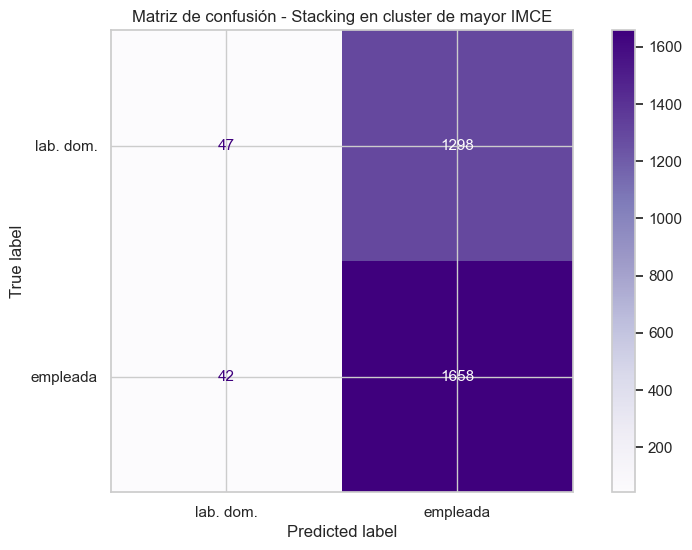

In [25]:
# Cluster con mayor IMCE promedio
cluster_max_imce = df.groupby('cluster')['imce'].mean().idxmax()
print(f"Cluster con mayor IMCE promedio: {cluster_max_imce} "
      f"(IMCE medio = {df.groupby('cluster')['imce'].mean().max():.3f})")

# Subconjunto: mayor IMCE y excluyendo desempleada
df_sub = df[(df['cluster'] == cluster_max_imce) & (df['madre_work'] != 0)].copy()
y_sub = (df_sub['madre_work'] == 1).astype(int).values
X_sub = df_sub[features].values
baseline_sub = np.bincount(y_sub).max() / len(y_sub)
print(f"Tamaño del subgrupo: {X_sub.shape[0]} | baseline: {baseline_sub:.4f}")

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_sub, y_sub, test_size=0.2,
                                              stratify=y_sub, random_state=RANDOM_STATE)

# Re-instanciamos el mejor modelo de la P5 (clon limpio)
from sklearn.base import clone
mejor_modelo = clone(modelos[mejor_p5])
t0 = time.time(); mejor_modelo.fit(Xs_tr, ys_tr); t_fit_sub = time.time() - t0
y_pred_sub = mejor_modelo.predict(Xs_te)

print(f"\nModelo re-estimado: {mejor_p5}")
print(f"Accuracy en el subgrupo: {accuracy_score(ys_te, y_pred_sub):.4f}  (baseline {baseline_sub:.4f})")
print(f"F1: {f1_score(ys_te, y_pred_sub):.4f} | tiempo fit: {t_fit_sub:.1f}s")
print("\nReporte de clasificación (subgrupo de mayor IMCE):")
print(classification_report(ys_te, y_pred_sub, target_names=['labor doméstica', 'empleada']))

ConfusionMatrixDisplay.from_predictions(ys_te, y_pred_sub, display_labels=['lab. dom.', 'empleada'],
                                        cmap='Purples')
plt.title(f'Matriz de confusión - {mejor_p5} en cluster de mayor IMCE')
plt.show()

Conclusiones. Al restringir la muestra al cluster de mayor IMCE (sobrepeso/obesidad), el mejor modelo de la Pregunta 5 alcanza una accuracy de ~0,56, nuevamente muy próxima al baseline del subgrupo (~0,558). La matriz de confusión mantiene el mismo patrón observado en la muestra completa, predicción casi exclusiva de la clase mayoritaria.

1. Condicionar sobre el grupo de riesgo nutricional no mejora la capacidad predictiva. El IMCE elevado no introduce una interacción que vuelva informativas a las habilidades socioemocionales respecto del empleo materno.
2. Se refuerza el hallazgo general realizado en el trabajo: las dimensiones socioemocionales del niño y el tipo de empleo de la madre son fenómenos esencialmente independientes en estos datos. El leve aumento de accuracy frente a la muestra completa se explica por el mayor baseline del subgrupo, no por un mejor poder clasificatorio del modelo.

## Pregunta 8: Procesamiento de Lenguaje Natural sobre la variable "narrative"

Siguiendo el flujo del notebook "Sentiment_Analysis.ipynb", tokenizamos los textos de la variable "narrative" (descripciones generadas a partir de "sk1"-"sk13"), los vectorizamos con "CountVectorizer" y entrenamos un SVM lineal (SVC) para clasificar "madre_work", excluyendo las variables "sk". El objetivo es contrastar si una representación puramente textual de las habilidades socioemocionales recupera más, igual o menos señal que los factor scores estructurados de la Pregunta 5.

In [26]:
# Tokenizador en español: minúsculas, solo alfabéticos, sin stopwords, longitud > 2
stop_es = set(stopwords.words('spanish'))
def tokenizar(texto):
    return [w.lower() for w in word_tokenize(str(texto))
            if w.isalpha() and w.lower() not in stop_es and len(w) > 2]

# Ejemplo de tokenización
ejemplo = df_clf['narrative'].iloc[0]
print("Texto original:\n", ejemplo[:160], "...")
print("\nTokens:", tokenizar(ejemplo)[:15])

Texto original:
 Las habilidades socioemocionales estan bien establecidas, con lo afectivo-emocional como area mas fuerte y la curiosidad e intereses cognitivos como la mas reza ...

Tokens: ['habilidades', 'socioemocionales', 'estan', 'bien', 'establecidas', 'area', 'mas', 'fuerte', 'curiosidad', 'intereses', 'cognitivos', 'mas', 'rezagada', 'solo', 'rara']


In [27]:
# Vectorización Bag-of-Words sobre la muestra de clasificación (mismo target, excluyendo sk)
df_txt = df[df['madre_work'] != 0].copy()
y_txt = (df_txt['madre_work'] == 1).astype(int).values

vectorizer = CountVectorizer(tokenizer=tokenizar, max_features=400)
X_txt = vectorizer.fit_transform(df_txt['narrative'])
print("Matriz documento-término:", X_txt.shape, "| vocabulario:", len(vectorizer.get_feature_names_out()))

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_txt, y_txt, test_size=0.2,
                                              stratify=y_txt, random_state=RANDOM_STATE)

# Modelo SVC lineal (contraparte textual del SVM de la P5)
t0 = time.time()
svc_txt = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)
svc_txt.fit(Xt_tr, yt_tr)
t_fit_txt = time.time() - t0
y_pred_txt = svc_txt.predict(Xt_te)

acc_txt = accuracy_score(yt_te, y_pred_txt)
print(f"\nSVC (texto)  acc={acc_txt:.4f} | f1={f1_score(yt_te, y_pred_txt):.4f} | fit={t_fit_txt:.2f}s")
print("\nReporte de clasificación:")
print(classification_report(yt_te, y_pred_txt, target_names=['labor doméstica', 'empleada']))

Matriz documento-término: (37545, 179) | vocabulario: 179



SVC (texto)  acc=0.5508 | f1=0.6814 | fit=0.33s

Reporte de clasificación:
                 precision    recall  f1-score   support

labor doméstica       0.52      0.16      0.24      3405
       empleada       0.56      0.88      0.68      4104

       accuracy                           0.55      7509
      macro avg       0.54      0.52      0.46      7509
   weighted avg       0.54      0.55      0.48      7509



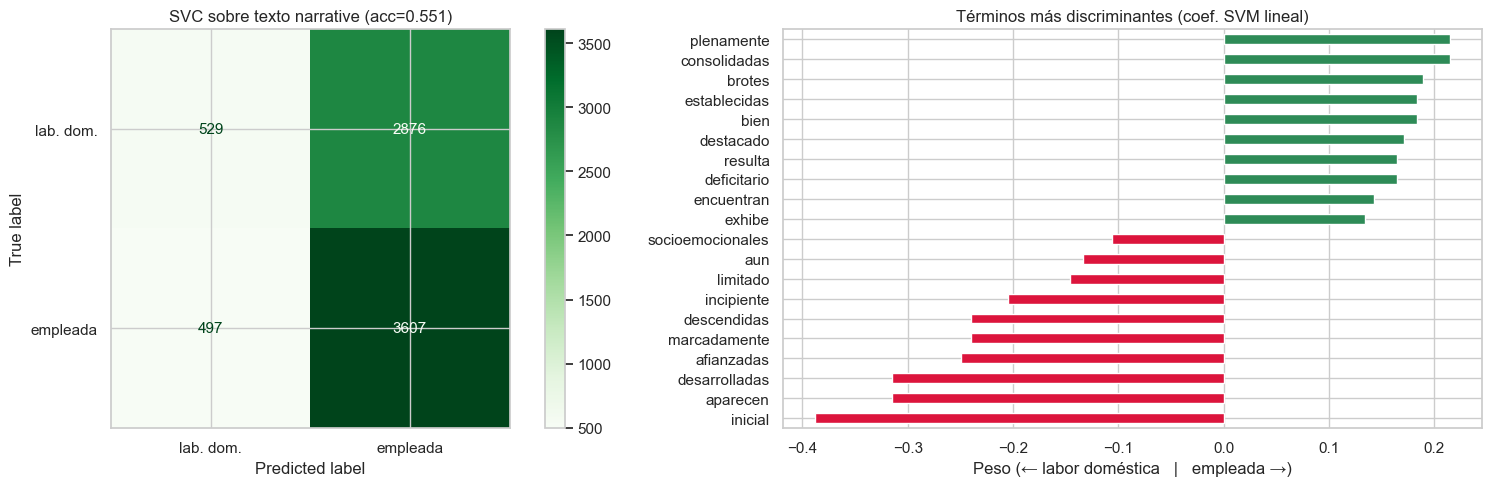

Comparación P5 (factor scores) vs P8 (texto):
  SVM estructurado (P5): acc = 0.5524
  SVC textual      (P8): acc = 0.5508
  Baseline mayoritario : 0.5465


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay.from_predictions(yt_te, y_pred_txt, display_labels=['lab. dom.', 'empleada'],
                                        cmap='Greens', ax=axes[0])
axes[0].set_title(f'SVC sobre texto narrative (acc={acc_txt:.3f})')

# Términos más discriminantes según el SVM lineal (coeficientes)
coefs = pd.Series(svc_txt.coef_[0], index=vectorizer.get_feature_names_out())
top = pd.concat([coefs.sort_values().head(10), coefs.sort_values().tail(10)])
top.plot.barh(ax=axes[1], color=['crimson']*10 + ['seagreen']*10)
axes[1].set_title('Términos más discriminantes (coef. SVM lineal)')
axes[1].set_xlabel('Peso (← labor doméstica   |   empleada →)')
plt.tight_layout(); plt.show()

# Comparación directa con el SVM de la Pregunta 5
print("Comparación P5 (factor scores) vs P8 (texto):")
print(f"  SVM estructurado (P5): acc = {resultados['SVM (RBF)']['accuracy']:.4f}")
print(f"  SVC textual      (P8): acc = {acc_txt:.4f}")
print(f"  Baseline mayoritario : {baseline:.4f}")

**Comparación y discusión.**

El SVC entrenado sobre el texto de "narrative" alcanza una accuracy de ~0,551, prácticamente idéntica a la del SVM estructurado de la Pregunta 5 (~0,552) y al baseline (0,546). Es un resultado coherente y esperable: dado que la variable "narrative" se genera a partir de los mismos "sk1"-"sk13", contiene en esencia la misma información que los factor scores, solo que codificada como lenguaje natural. Ambas representaciones numérica latente y textual recuperan la misma cantidad de señal sobre el empleo materno.

Hallazgos adicionales:
- La representación textual, pese a ser de mayor dimensión (cientos de términos), no aporta poder predictivo extra: el techo lo impone la información subyacente, no la forma de representarla.
- En eficiencia, el SVM lineal sobre la matriz dispersa documento-término es mucho más rápido que el SVM RBF de la P5 sobre features densos, ilustrando por qué los kernels lineales son el estándar en clasificación de texto de alta dimensión.
- Los términos más discriminantes tienen pesos pequeños, confirmando que ningún patrón lingüístico separa con fuerza a las clases.

Se confirma desde una metodología independiente la conclusión central del trabajo: las habilidades socioemocionales del estudiante, ya sea medidas como factores latentes o descritas en texto, no permiten discriminar el tipo de empleo de la madre.

## Conclusiones generales

1. Estructura latente (P2-P3). Los 13 ítems socioemocionales se resumen en tres factores correlacionados (Curiosidad cognitiva, Expresión afectivo-emocional e Interacción social), con buena adecuación muestral (KMO 0,87), consistencia interna aceptable ($\alpha$ 0,78) y un CFA de buen ajuste (CFI 0,95; RMSEA 0,05). El ítem "sk7" (agresividad) resultó no informativo y fue excluido.

2. Clasificación supervisada (P4-P5-P7). Random Forest, XGBoost, SVM y Stacking obtienen desempeños equivalentes y cercanos al baseline (~0,55). Las matrices de confusión muestran que los modelos colapsan a la clase mayoritaria. En eficiencia, XGBoost ofrece la mejor relación costo-beneficio frente al mayor costo del SVM y del Stacking. Restringir al grupo de mayor IMCE (P7) no cambia el resultado.

3. Segmentación nutricional (P6). El clustering identifica tres perfiles, dominados por el IMCE, con un grupo de sobrepeso/obesidad (mayor IMCE) y un grupo físicamente activo.

4. NLP (P8). El modelo de texto sobre "narrative" reproduce el mismo desempeño que los factores estructurados, lo que valida la conclusión por una vía independiente.

En definitiva, las habilidades socioemocionales del niño se muestran prácticamente independientes del tipo de empleo materno en esta muestra. Que distintos algoritmos, desde árboles hasta NLP, lleguen a la misma respuesta refuerza esa lectura.